In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Set visualization aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [8]:
# Load the dataset
df = pd.read_csv('house_prices_train.csv')

print("📊 Dataset Sample:")
print(df[['GrLivArea', 'BedroomAbvGr', 'FullBath', 'SalePrice']].head())

📊 Dataset Sample:
   GrLivArea  BedroomAbvGr  FullBath  SalePrice
0       1748             4         3     330265
1       1430             1         3     256422
2       1823             3         1     291241
3       2261             5         3     382996
4       1382             3         3     291132


In [9]:
# Define Features (X) and Target (y)
features = ['GrLivArea', 'BedroomAbvGr', 'FullBath']
X = df[features].values
y = df['SalePrice'].values

# Split into 80% training data and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape[0]} rows")

Training data size: 800 rows


In [10]:
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("✅ Multiple Regression model trained successfully.")
print(f"Base Price (Intercept): ${model.intercept_:,.2f}")
print(f"Value per SqFt: ${model.coef_[0]:,.2f}")
print(f"Value per Bedroom: ${model.coef_[1]:,.2f}")
print(f"Value per Bathroom: ${model.coef_[2]:,.2f}")

✅ Multiple Regression model trained successfully.
Base Price (Intercept): $9,739.64
Value per SqFt: $111.57
Value per Bedroom: $10,626.44
Value per Bathroom: $28,276.45


C:\Users\BENJITH BABU\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127969 (\N{HOUSE WITH GARDEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


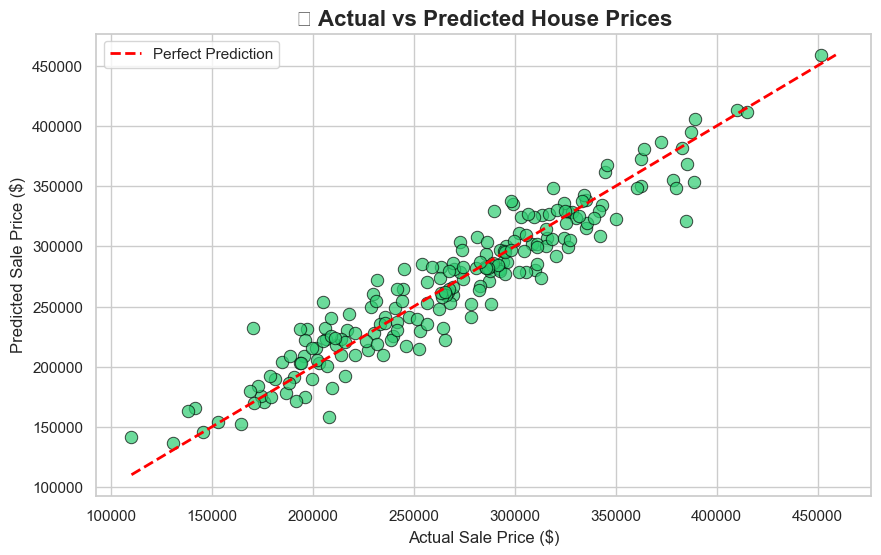

📊 Overall R² Score: 0.9026


In [11]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Plot Actual vs. Predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, color='#2ecc71', s=80, alpha=0.7, edgecolor='black')

# Plot a reference diagonal line (Perfect Prediction)
max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linewidth=2, linestyle='--', label='Perfect Prediction')

plt.title('🏡 Actual vs Predicted House Prices', fontsize=16, fontweight='bold')
plt.xlabel('Actual Sale Price ($)', fontsize=12)
plt.ylabel('Predicted Sale Price ($)', fontsize=12)
plt.legend()
plt.show()

# Print metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f"📊 Overall R² Score: {r2:.4f}")

In [12]:
def predict_house_price(area, beds, baths):
    # Notice we pass a 2D array matching the 3 features
    prediction = model.predict([[area, beds, baths]])[0]
    print(f"\n🔮 Prediction for a {beds}-Bed, {baths}-Bath house with {area} sq ft:")
    print(f"Estimated Price: ${prediction:,.2f}")

try:
    print("\n--- 🏡 House Price Estimator ---")
    user_area = float(input("Enter Living Area (sq ft): "))
    user_beds = float(input("Enter Number of Bedrooms: "))
    user_baths = float(input("Enter Number of Full Baths: "))
    
    predict_house_price(user_area, user_beds, user_baths)
except ValueError:
    print("❌ Invalid input! Please enter numbers only.")


--- 🏡 House Price Estimator ---

🔮 Prediction for a 4.0-Bed, 3.0-Bath house with 12.0 sq ft:
Estimated Price: $138,413.61
